# **CS 5361/6361 Machine Learning**

**CNNs to classify CIFAR-10**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from keras import callbacks
import cv2 as cv

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [ ]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Final shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Final shapes
x_train.shape = (50000, 32, 32, 3)
y_train.shape = (50000, 10)
x_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 10)


Let's see some of the images in the dataset and their mirrored versions:

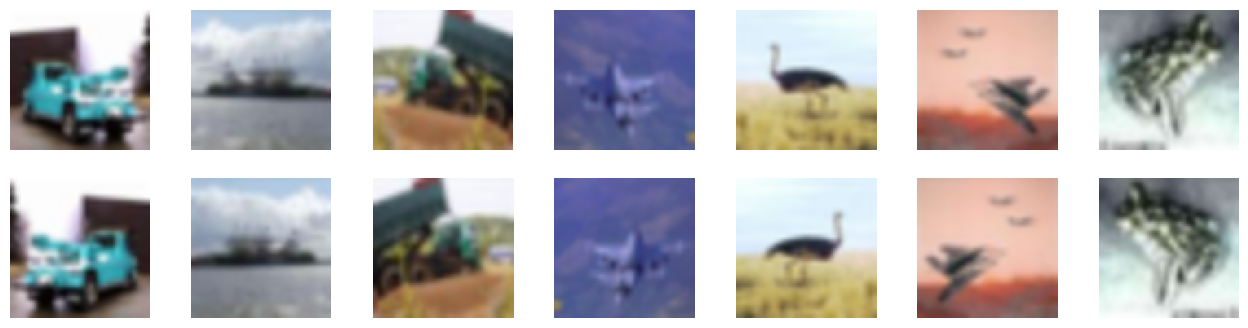

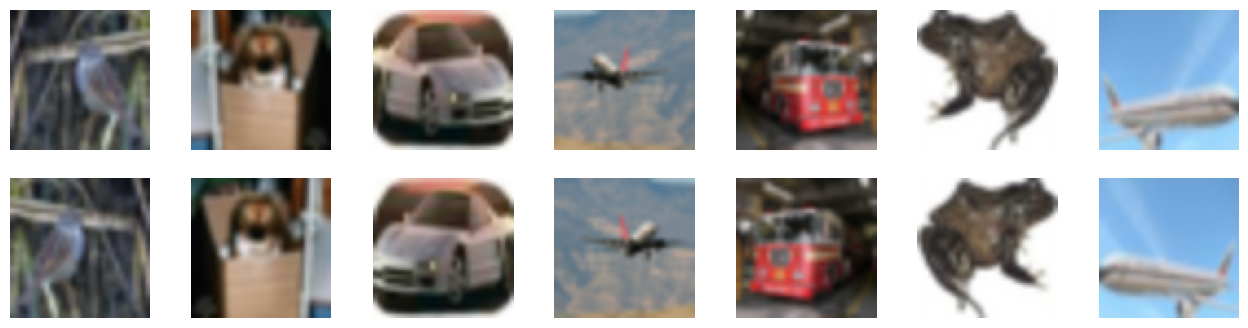

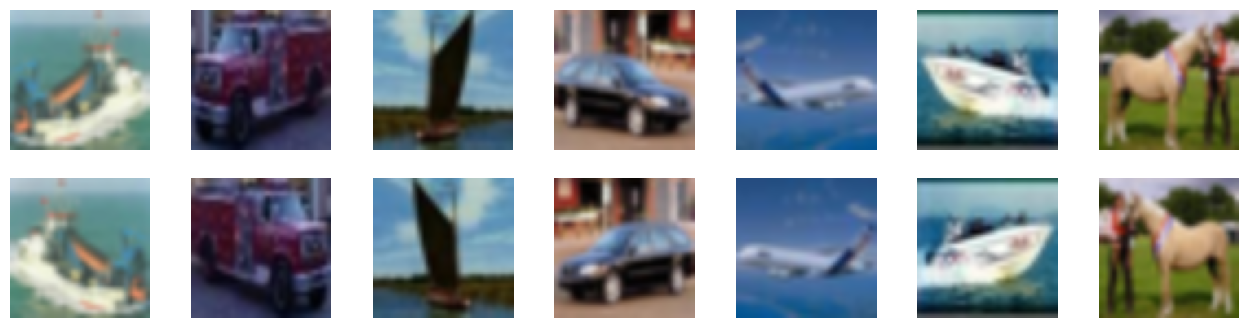

In [ ]:
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 7)
  k = 2
  fig, ax = plt.subplots(nrows=2,ncols=len(sel), figsize=(16,4))
  for i,s in enumerate(sel):
    ax[0,i].imshow(cv.resize(x_train[s], (32*k, 32*k)))
    ax[1,i].imshow(cv.resize(x_train[s,:,::-1], (32*k, 32*k)))
    ax[0,i].set_axis_off()
    ax[1,i].set_axis_off()

# Original code with early stopping

Instead of running the fit process for a fixed number of epoch, we will add an instruction to stop if results don't improve for a predetermined number of epochs.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,730 (424.73 KB)

 Trainable params: 108,730 (424.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
500/500 - 5s - 11ms/step - accuracy: 0.4240 - loss: 1.5838 - val_accuracy: 0.5279 - val_loss: 1.3176
Epoch 2/100
500/500 - 2s - 5ms/step - accuracy: 0.5747 - loss: 1.1909 - val_accuracy: 0.6130 - val_loss: 1.0984
Epoch 3/100
500/500 - 2s - 4ms/step - accuracy: 0.6383 - loss: 1.0285 - val_accuracy: 0.6213 - val_loss: 1.0607
Epoch 4/100
500/500 - 2s - 5ms/step - accuracy: 0.6770 - loss: 0.9241 - val_accuracy: 0.6663 - val_loss: 0.9553
Epoch 5/100
500/500 - 2s - 5ms/step - accuracy: 0.7052 - loss: 0.8422 - val_accuracy: 0.6911 - val_loss: 0.8971
Epoch 6/100
500/500 - 2s - 5ms/step - accuracy: 0.7262 - loss: 0.7844 - val_accuracy: 0.7060 - val_loss: 0.8542
Epoch 7/100
500/500 - 2s - 5ms/step - accuracy: 0.7421 - loss: 0.7403 - val_accuracy: 0.7158 - val_loss: 0.8355
Epoch 8/100
500/500 - 2s - 5ms/step - accuracy: 0.7598 - loss: 0.6919 - val_accuracy: 0.7152 - val_loss: 0.8398
Epoch 9/100
500/500 - 2s - 5ms/step - accuracy: 0.7734 - loss: 0.6533 - val_accuracy: 0.7033 - val_loss

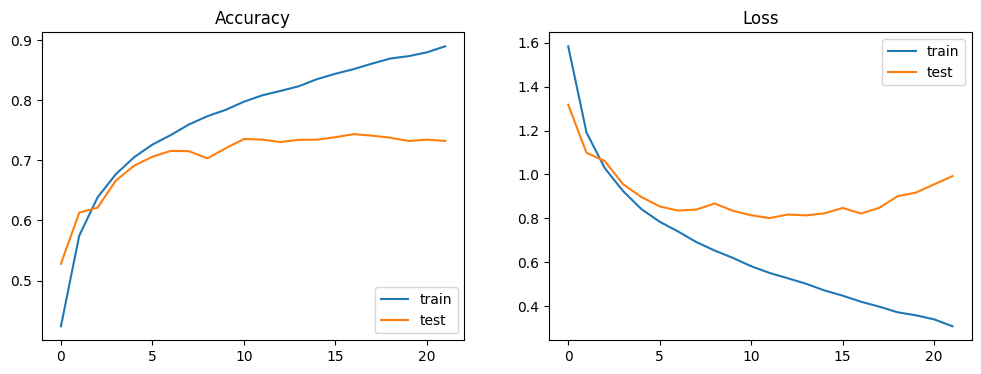

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 54.7148 secs
Accuracy = 0.7436


In [ ]:
earlystopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 100,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
    callbacks = [earlystopping]
)
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print_best_metrics(history.history)
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))




# Back-to-back convolutional layers

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
500/500 - 8s - 16ms/step - accuracy: 0.4156 - loss: 1.5874 - val_accuracy: 0.5441 - val_loss: 1.2767
Epoch 2/100
500/500 - 4s - 8ms/step - accuracy: 0.5953 - loss: 1.1395 - val_accuracy: 0.6337 - val_loss: 1.0334
Epoch 3/100
500/500 - 4s - 8ms/step - accuracy: 0.6755 - loss: 0.9197 - val_accuracy: 0.6826 - val_loss: 0.8963
Epoch 4/100
500/500 - 4s - 8ms/step - accuracy: 0.7233 - loss: 0.7895 - val_accuracy: 0.7053 - val_loss: 0.8491
Epoch 5/100
500/500 - 4s - 8ms/step - accuracy: 0.7564 - loss: 0.6910 - val_accuracy: 0.7260 - val_loss: 0.8029
Epoch 6/100
500/500 - 4s - 8ms/step - accuracy: 0.7836 - loss: 0.6164 - val_accuracy: 0.7489 - val_loss: 0.7320
Epoch 7/100
500/500 - 4s - 8ms/step - accuracy: 0.8062 - loss: 0.5517 - val_accuracy: 0.7571 - val_loss: 0.7208
Epoch 8/100
500/500 - 4s - 8ms/step - accuracy: 0.8252 - loss: 0.4969 - val_accuracy: 0.7612 - val_loss: 0.7059
Epoch 9/100
500/500 - 4s - 8ms/step - accuracy: 0.8437 - loss: 0.4442 - val_accuracy: 0.7569 - val_loss

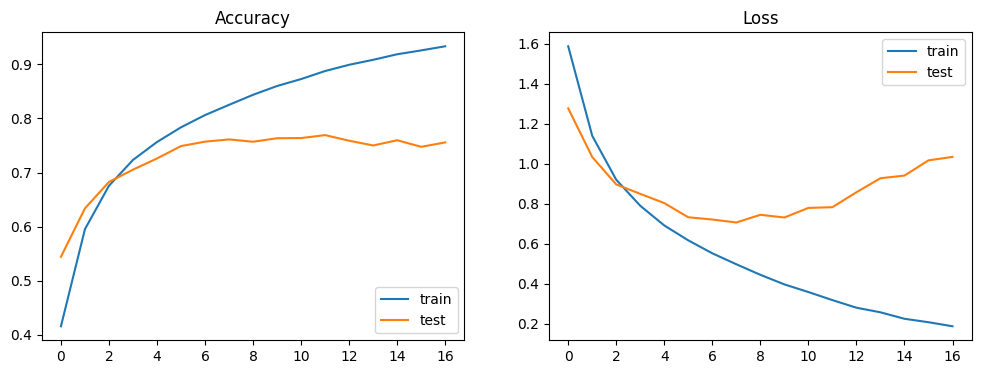

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 75.3963 secs
Accuracy = 0.7692


In [ ]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 100,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
    callbacks = [earlystopping]
)
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print_best_metrics(history.history)
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))


# Adding mirrored training data

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3857 - loss: 1.6719 - val_accuracy: 0.6473 - val_loss: 1.0125
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6678 - loss: 0.9485 - val_accuracy: 0.7208 - val_loss: 0.8008
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7414 - loss: 0.7344 - val_accuracy: 0.7550 - val_loss: 0.7276
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7873 - loss: 0.6090 - val_accuracy: 0.7708 - val_loss: 0.6704
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8128 - loss: 0.5374 - val_accuracy: 0.7766 - val_loss: 0.6621
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8347 - loss: 0.4748 - val_accuracy: 0.7816 - val_loss: 0.6583
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8481 - loss: 0.4311 - val_accuracy: 0.7934 - val_loss: 0.6326
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8678 - loss: 

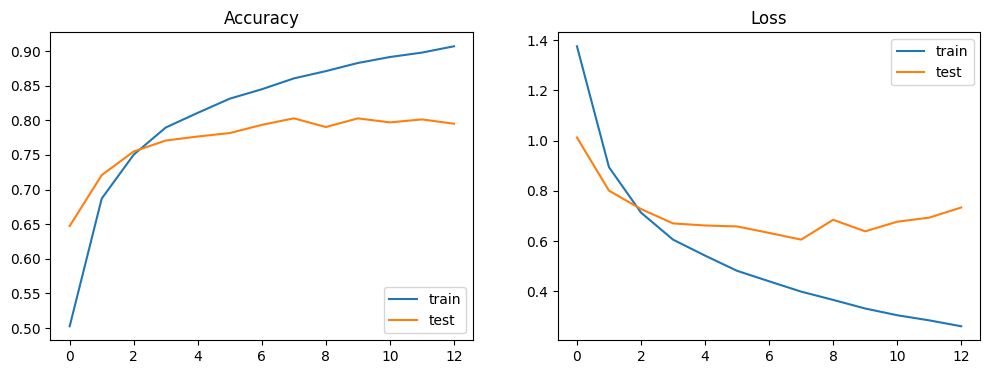

The highest training accuracy was 0.9070 obtained in epoch 13
The final training accuracy was 0.9070
The highest validation accuracy was 0.8029 obtained in epoch 8
The final validation accuracy was 0.7951
The lowest training loss was 0.2609 obtained in epoch 13
The final training loss was 0.2609
The lowest validation loss was 0.6058 obtained in epoch 8
The final validation loss was 0.7337
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Elapsed time training= 113.3436 secs
Mean squared error = 0.028
Accuracy = 0.8029


In [ ]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

# Adding mirrored test data

Since the training is identical, we don't need to retrain the model. We will use the model from the previous question.

In [ ]:
y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

Model accuracy on test set: 0.8002
Model accuracy on mirrored test set: 0.8044
Model accuracy on combined original and mirrored test set: 0.8331


# Adding dropout

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3145 - loss: 1.8457 - val_accuracy: 0.6103 - val_loss: 1.0831
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6020 - loss: 1.1220 - val_accuracy: 0.6944 - val_loss: 0.8697
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6640 - loss: 0.9519 - val_accuracy: 0.7251 - val_loss: 0.7864
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7021 - loss: 0.8512 - val_accuracy: 0.7464 - val_loss: 0.7431
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7261 - loss: 0.7827 - val_accuracy: 0.7640 - val_loss: 0.6808
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7453 - loss: 0.7368 - val_accuracy: 0.7802 - val_loss: 0.6417
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7595 - loss: 0.6967 - val_accuracy: 0.7797 - val_loss: 0.6477
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7686 - loss: 

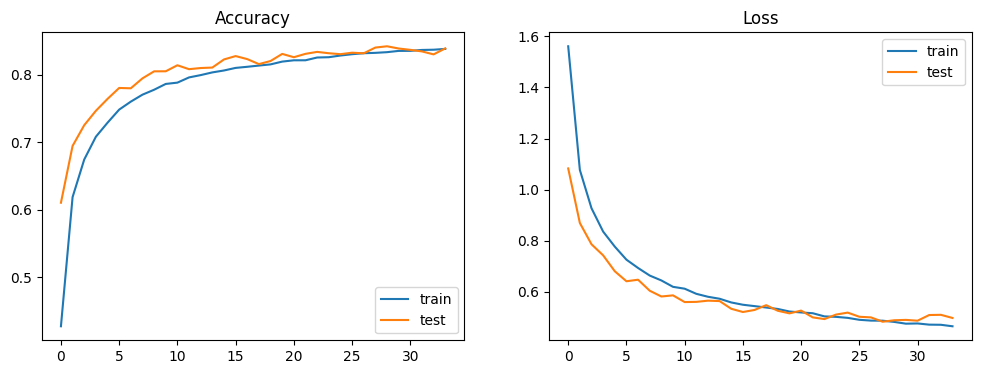

The highest training accuracy was 0.8380 obtained in epoch 34
The final training accuracy was 0.8380
The highest validation accuracy was 0.8419 obtained in epoch 29
The final validation accuracy was 0.8388
The lowest training loss was 0.4654 obtained in epoch 34
The final training loss was 0.4654
The lowest validation loss was 0.4833 obtained in epoch 28
The final validation loss was 0.4980
Model accuracy on test set: 0.8419
Model accuracy on mirrored test set: 0.8413
Model accuracy on combined original and mirrored test set: 0.8562


In [ ]:
def cnn(input_shape, conv_units,dense_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64,0.25)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)
print_best_metrics(history.history)

y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

# Adding batch normalization

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,522 (689.54 KB)

 Trainable params: 176,106 (687.91 KB)

 Non-trainable params: 416 (1.62 KB)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4069 - loss: 1.7040 - val_accuracy: 0.5675 - val_loss: 1.2212
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6611 - loss: 0.9597 - val_accuracy: 0.7136 - val_loss: 0.8228
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7262 - loss: 0.7850 - val_accuracy: 0.7365 - val_loss: 0.7559
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7618 - loss: 0.6892 - val_accuracy: 0.7294 - val_loss: 0.7991
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7796 - loss: 0.6341 - val_accuracy: 0.7768 - val_loss: 0.6486
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7983 - loss: 0.5815 - val_accuracy: 0.8099 - val_loss: 0.5695
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8072 - loss: 0.5573 - val_accuracy: 0.8095 - val_loss: 0.5617
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8178 - loss:

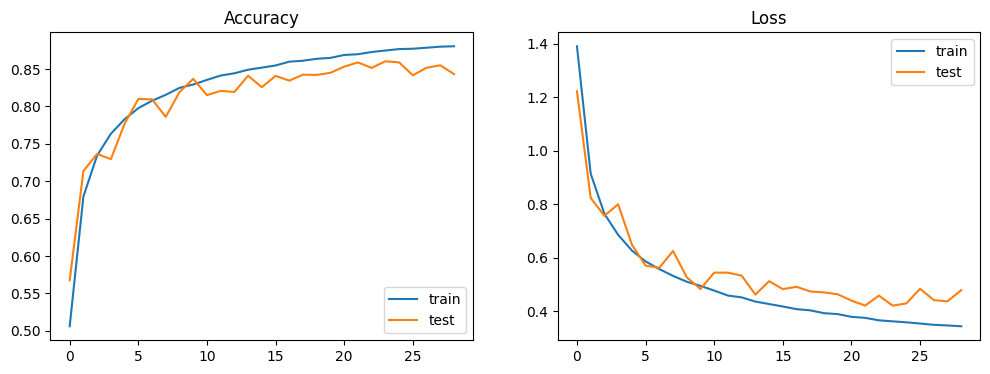

The highest training accuracy was 0.8804 obtained in epoch 29
The final training accuracy was 0.8804
The highest validation accuracy was 0.8603 obtained in epoch 24
The final validation accuracy was 0.8432
The lowest training loss was 0.3429 obtained in epoch 29
The final training loss was 0.3429
The lowest validation loss was 0.4201 obtained in epoch 24
The final validation loss was 0.4782
Model accuracy on test set: 0.8603
Model accuracy on mirrored test set: 0.8599
Model accuracy on combined original and mirrored test set: 0.8707


In [ ]:
def cnn(input_shape, conv_units,dense_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64,0.25)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)
print_best_metrics(history.history)

y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_61 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,522 (689.54 KB)

 Trainable params: 176,106 (687.91 KB)

 Non-trainable params: 416 (1.62 KB)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.3649 - loss: 1.8089 - val_accuracy: 0.5745 - val_loss: 1.2457
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6402 - loss: 1.0174 - val_accuracy: 0.7006 - val_loss: 0.8378
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7123 - loss: 0.8274 - val_accuracy: 0.7536 - val_loss: 0.7149
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7397 - loss: 0.7468 - val_accuracy: 0.7552 - val_loss: 0.7071
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7658 - loss: 0.6768 - val_accuracy: 0.7847 - val_loss: 0.6258
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7799 - loss: 0.6383 - val_accuracy: 0.7571 - val_loss: 0.7125
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7899 - loss: 0.6075 - val_accuracy: 0.8015 - val_loss: 0.5856
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8030 - loss:

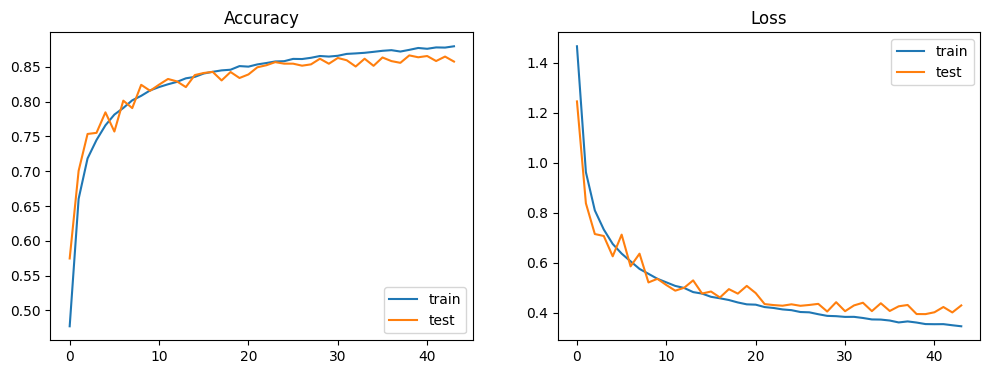

The highest training accuracy was 0.8797 obtained in epoch 44
The final training accuracy was 0.8797
The highest validation accuracy was 0.8666 obtained in epoch 39
The final validation accuracy was 0.8577
The lowest training loss was 0.3458 obtained in epoch 44
The final training loss was 0.3458
The lowest validation loss was 0.3945 obtained in epoch 40
The final validation loss was 0.4292
Model accuracy on test set: 0.8666
Model accuracy on mirrored test set: 0.8664
Model accuracy on combined original and mirrored test set: 0.8759


In [ ]:
def cnn(input_shape, conv_units,dense_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(dropout_rate))
    model.add(BatchNormalization())
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(BatchNormalization())
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64,0.25)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)
print_best_metrics(history.history)

y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,018 (949.29 KB)

 Trainable params: 242,474 (947.16 KB)

 Non-trainable params: 544 (2.12 KB)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.3816 - loss: 1.7680 - val_accuracy: 0.1985 - val_loss: 2.6473
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6307 - loss: 1.0407 - val_accuracy: 0.3680 - val_loss: 1.9670
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7026 - loss: 0.8572 - val_accuracy: 0.3980 - val_loss: 1.7855
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7365 - loss: 0.7632 - val_accuracy: 0.4282 - val_loss: 1.8898
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7555 - loss: 0.7106 - val_accuracy: 0.5378 - val_loss: 1.3140
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7730 - loss: 0.6668 - val_accuracy: 0.5015 - val_loss: 1.4245
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7832 - loss: 0.6276 - val_accuracy: 0.5178 - val_loss: 1.4907
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7918 - los

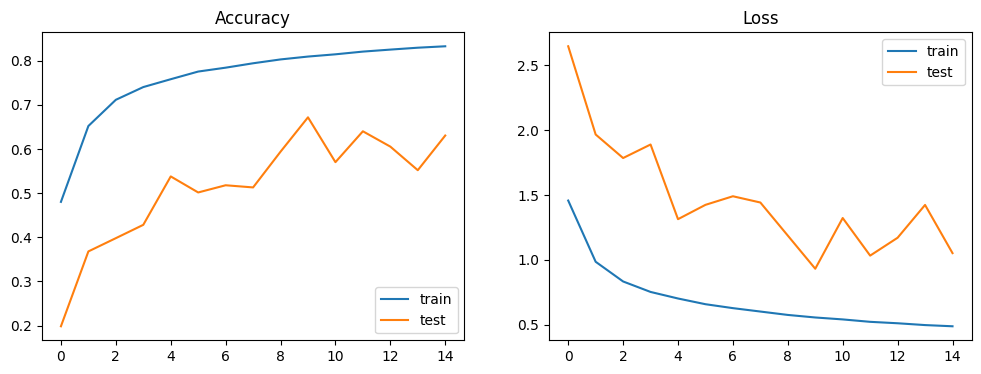

The highest training accuracy was 0.8325 obtained in epoch 15
The final training accuracy was 0.8325
The highest validation accuracy was 0.6716 obtained in epoch 10
The final validation accuracy was 0.6304
The lowest training loss was 0.4880 obtained in epoch 15
The final training loss was 0.4880
The lowest validation loss was 0.9317 obtained in epoch 10
The final validation loss was 1.0521
Model accuracy on test set: 0.6716
Model accuracy on mirrored test set: 0.6738
Model accuracy on combined original and mirrored test set: 0.6806


In [ ]:
def cnn(input_shape, conv_units,dense_units,dropout_rate):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Dropout(dropout_rate))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())


  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(BatchNormalization())
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],128,0.5)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()

history = model.fit(
  np.append(x_train,x_train[:,:,::-1],axis=0), np.append(y_train,y_train,axis=0),
  epochs = 100,
  batch_size=100,
  verbose = 1,
  validation_data=(x_test, y_test),
  callbacks = [earlystopping]
)

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)
print_best_metrics(history.history)

y_test_class = np.argmax(y_test,axis=1)
pred1 = model.predict(x_test,verbose=0) # Prediction
pred2 = model.predict(x_test[:,:,::-1],verbose=0)
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_test_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_test_class)))
avg_pred = (pred1+pred2)/2
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(avg_pred,axis=1),y_test_class)))